# Proyecto de Primer Corte — Fundamentos Probabilísticos del Machine Learning
## Propuesta B — Analista de riesgo clínico para una red de clínicas cardiológicas

**Aprendizaje de Máquina No Supervisado · Universidad de La Sabana · 2026-II**

---

### Escenario profesional

Actúo como analista de datos de una red de clínicas cardiológicas. La dirección médica quiere
responder dos preguntas operativas:

1. **¿Qué información clínica mueve realmente la sospecha de enfermedad coronaria** y cuál es
   solo ruido costoso?
2. **¿En qué orden y con qué pruebas** debería la clínica actualizar su creencia sobre un paciente,
   para no gastar recursos en exámenes que no cambian la decisión?

Todo el análisis está construido sobre los 11 conceptos probabilísticos del Primer Corte, cada uno
respondiendo una pregunta clínica concreta —no como una lista de ejercicios.

### Dataset

**Heart Disease Dataset (Cleveland) — UCI Machine Learning Repository**
Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). *Heart disease* [Data set].
UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X

303 pacientes, 14 atributos clínicos. Licencia CC BY 4.0.

> **Nota de reproducibilidad:** el dataset se descarga directamente desde el UCI Machine Learning
> Repository con el paquete oficial `ucimlrepo` (`fetch_ucirepo(id=45)`), tal como lo indica la
> propia página del repositorio. La celda de carga guarda además una copia local en
> `data/heart_cleveland.csv` y la usa como respaldo si el servidor de UCI no está accesible, de modo
> que el notebook corre de principio a fin con o sin conexión. Los valores faltantes (`?` en el
> archivo original) llegan como `NaN` y se tratan explícitamente más abajo.
>


## 0. Imports y carga de datos

In [1]:
!pip -q install ucimlrepo

In [2]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Modelos y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

import itertools
import os
import warnings

warnings.filterwarnings("ignore")

# Semilla
SEED = 42
np.random.seed(SEED)

# Colores para los gráficos
AZUL = "#0E2841"
ORO = "#BC8F00"
MORADO = "#734393"

plt.rcParams["figure.dpi"] = 110

In [3]:
# Cargar dataset Heart Disease (Cleveland)

COLUMNAS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
            "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

RUTA_LOCAL = "data/heart_cleveland.csv"

try:
    from ucimlrepo import fetch_ucirepo

    heart_disease = fetch_ucirepo(id=45)

    X_uci = heart_disease.data.features
    y_uci = heart_disease.data.targets

    df_raw = pd.concat([X_uci[COLUMNAS], y_uci], axis=1)
    df_raw = df_raw.rename(columns={df_raw.columns[-1]: "num"})

    FUENTE = "UCI (id=45)"

    os.makedirs("data", exist_ok=True)
    df_raw.to_csv(RUTA_LOCAL, index=False)

except Exception as e:

    # Si falla la descarga, usar copia local
    df_raw = pd.read_csv(RUTA_LOCAL)

    FUENTE = f"Copia local ({type(e).__name__})"

print("Fuente:", FUENTE)
print("Número de filas:", len(df_raw))

print("\nValores faltantes:")
print(df_raw.isna().sum()[lambda s: s > 0].to_string())

print("\nDistribución de 'num':")
print(df_raw["num"].value_counts().sort_index().to_string())

Fuente: UCI (id=45)
Número de filas: 303

Valores faltantes:
ca      4
thal    2

Distribución de 'num':
num
0    164
1     55
2     36
3     35
4     13


**Diccionario de variables (base de Cleveland, UCI):**

| Variable | Significado |
|---|---|
| `age` | Edad del paciente, en años |
| `sex` | Sexo (1 = hombre, 0 = mujer) |
| `cp` | Tipo de dolor de pecho (1 = angina típica, 2 = angina atípica, 3 = dolor no anginoso, 4 = asintomático) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Azúcar en sangre en ayunas > 120 mg/dl (1 = sí, 0 = no) |
| `restecg` | Electrocardiograma en reposo (0, 1, 2) |
| `thalach` | Frecuencia cardíaca máxima alcanzada en prueba de esfuerzo |
| `exang` | Angina inducida por ejercicio (1 = sí, 0 = no) |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST en el pico del ejercicio |
| `ca` | Número de vasos principales (0–3) coloreados por fluoroscopia |
| `thal` | Prueba de talio (3 = normal, 6 = defecto fijo, 7 = defecto reversible) |
| `num` | **Variable objetivo:** 0 = sin enfermedad, 1–4 = enfermedad presente |

**Decisión de preprocesamiento:** Hay 6 pacientes con valores faltantes: 4 en `ca` y 2 en `thal`. Como representan aproximadamente el 2% de la base y el porcentaje es pequeño, decidimos eliminar estos registros mediante *listwise deletion*. Con esto quedan **297 pacientes**, que serán la base utilizada para los análisis posteriores.

La variable objetivo `num` también se transforma en una variable binaria. Se define `enfermedad = 1` cuando `num ≥ 1` y `enfermedad = 0` cuando `num = 0`. Esto permite trabajar con la presencia o ausencia de enfermedad coronaria, en lugar de analizar los diferentes niveles de severidad.

In [4]:
# Limpieza y variable objetivo

df = df_raw.dropna().reset_index(drop=True).copy()

# Convertir num en una variable binaria
df["enfermedad"] = (df["num"] >= 1).astype(int)

# Etiquetas para los gráficos
df["cp_label"] = df["cp"].map({
    1: "Angina típica",
    2: "Angina atípica",
    3: "No anginoso",
    4: "Asintomático"
})

N = len(df)

print(f"n analítico = {N} (se eliminaron {len(df_raw) - N} pacientes)")
print(
    df["enfermedad"]
    .value_counts()
    .rename({0: "Sin enfermedad", 1: "Con enfermedad"})
    .to_string()
)

df.head()

n analítico = 297 (se eliminaron 6 pacientes)
enfermedad
Sin enfermedad    160
Con enfermedad    137


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,enfermedad,cp_label
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0,Angina típica
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1,Asintomático
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1,Asintomático
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0,No anginoso
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0,Angina atípica


## 1. Probabilidad condicional

**Pregunta clínica:** ¿el tipo de dolor de pecho que reporta el paciente cambia la probabilidad de
que efectivamente tenga enfermedad coronaria?

Comparamos la probabilidad marginal $P(D)$ contra la condicional $P(D \mid \text{cp})$ para cada
uno de los cuatro tipos de dolor.

In [5]:
# Probabilidad marginal P(D)
p_D = df["enfermedad"].mean()

# Probabilidad condicional P(D | cp = asintomático)
mask_asint = df["cp"] == 4

p_D_asint = df.loc[mask_asint, "enfermedad"].mean()
p_D_no_asint = df.loc[~mask_asint, "enfermedad"].mean()

print(f"P(D)                      = {p_D:.4f}   ({p_D:.1%})")
print(f"P(D | cp = Asintomático)  = {p_D_asint:.4f}   ({p_D_asint:.1%})  n = {mask_asint.sum()}")
print(f"P(D | cp != Asintomático) = {p_D_no_asint:.4f}   ({p_D_no_asint:.1%})")
print(f"Razón de riesgo (lift)    = {p_D_asint / p_D:.2f}x sobre la tasa base")

# Desglose por tipo de dolor
tabla_cp = (
    df.groupby("cp_label")
      .agg(n=("enfermedad", "size"), P_D=("enfermedad", "mean"))
      .sort_values("P_D", ascending=False)
)

print("\nP(D | cada tipo de dolor de pecho):")
print(tabla_cp.round(4).to_string())

P(D)                      = 0.4613   (46.1%)
P(D | cp = Asintomático)  = 0.7254   (72.5%)  n = 142
P(D | cp != Asintomático) = 0.2194   (21.9%)
Razón de riesgo (lift)    = 1.57x sobre la tasa base

P(D | cada tipo de dolor de pecho):
                  n     P_D
cp_label                   
Asintomático    142  0.7254
Angina típica    23  0.3043
No anginoso      83  0.2169
Angina atípica   49  0.1837


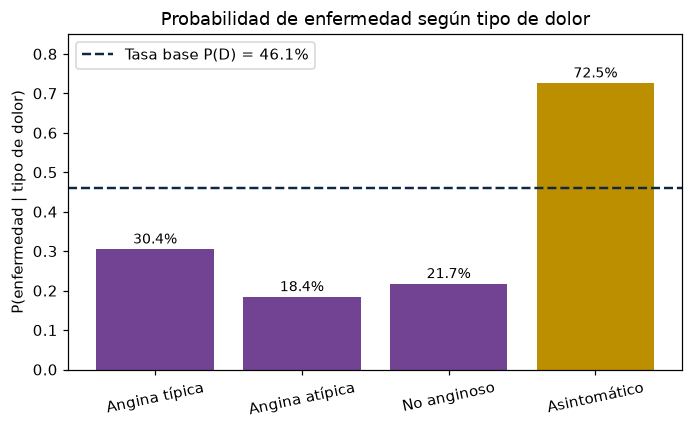

In [6]:
# Gráfico de probabilidad de enfermedad por tipo de dolor

orden = ["Angina típica", "Angina atípica", "No anginoso", "Asintomático"]
tasas = df.groupby("cp_label")["enfermedad"].mean().reindex(orden)

fig = plt.figure(figsize=(6.4, 4))

plt.bar(
    tasas.index,
    tasas.values,
    color=[MORADO, MORADO, MORADO, ORO]
)

plt.axhline(
    p_D,
    color=AZUL,
    ls="--",
    lw=1.6,
    label=f"Tasa base P(D) = {p_D:.1%}"
)

for i, v in enumerate(tasas.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=9)

plt.ylabel("P(enfermedad | tipo de dolor)")
plt.title("Probabilidad de enfermedad según tipo de dolor")
plt.xticks(rotation=12)
plt.ylim(0, 0.85)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación clínica:** 

El resultado es un poco contraintuitivo, pero justamente por eso es importante. El grupo **asintomático** presenta una probabilidad de enfermedad del **72.5%**, bastante mayor que el **46.1%** de la base general y que el **21.9%** de los demás tipos de dolor.

Esto muestra que, en esta muestra, no tener síntomas típicos de angina no significa tener un menor riesgo de enfermedad. Por eso, el tipo de dolor por sí solo no sería suficiente para descartar la presencia de enfermedad coronaria.

## 2. Teorema de Bayes

**Pregunta clínica:** 
Llega el resultado de la prueba de esfuerzo y el paciente presentó **angina inducida por ejercicio** (`exang = 1`). La pregunta es cuánto cambia la probabilidad de enfermedad después de conocer este resultado.

El Teorema de Bayes permite calcular la probabilidad de tener la enfermedad dado que el paciente presentó angina inducida por ejercicio:

$$
P(\text{enfermedad} \mid \text{angina}) =
\frac{P(\text{angina} \mid \text{enfermedad})P(\text{enfermedad})}
{P(\text{angina})}
$$

La diferencia está en el orden de las probabilidades. $P(\text{angina} \mid \text{enfermedad})$ responde qué tan frecuente es la angina entre los pacientes que tienen la enfermedad. En cambio, $P(\text{enfermedad} \mid \text{angina})$ responde la pregunta que nos interesa: qué tan probable es que el paciente tenga la enfermedad sabiendo que presentó angina.

In [7]:
# Probabilidades necesarias para Bayes

p_E_dado_D = df.loc[df.enfermedad == 1, "exang"].mean()
p_E_dado_noD = df.loc[df.enfermedad == 0, "exang"].mean()
prior = p_D

# Probabilidad total de presentar angina
p_E = p_E_dado_D * prior + p_E_dado_noD * (1 - prior)

# Probabilidad de enfermedad dado que presentó angina
posterior_exang = (p_E_dado_D * prior) / p_E

# Verificación por conteo directo
verificacion = df.loc[df.exang == 1, "enfermedad"].mean()

print(f"P(E | D)   = {p_E_dado_D:.4f}      (sensibilidad)")
print(f"P(E | ¬D)  = {p_E_dado_noD:.4f}      (falsos positivos)")
print(f"P(D)       = {prior:.4f}      (prior)")
print(f"P(E)       = {p_E:.4f}")

print(f"\nP(D | E) por Bayes  = {posterior_exang:.4f}   ({posterior_exang:.1%})")
print(f"P(D | E) por conteo = {verificacion:.4f}")

print(f"\nRazón de verosimilitud LR+ = {p_E_dado_D / p_E_dado_noD:.2f}")

print(
    f"La probabilidad pasa de {prior:.1%} a {posterior_exang:.1%} "
    f"(+{(posterior_exang - prior) * 100:.1f} puntos porcentuales)"
)

P(E | D)   = 0.5401      (sensibilidad)
P(E | ¬D)  = 0.1437      (falsos positivos)
P(D)       = 0.4613      (prior)
P(E)       = 0.3266

P(D | E) por Bayes  = 0.7629   (76.3%)
P(D | E) por conteo = 0.7629

Razón de verosimilitud LR+ = 3.76
La probabilidad pasa de 46.1% a 76.3% (+30.2 puntos porcentuales)


**Interpretación clínica:** La angina inducida por ejercicio aparece **3.76 veces más en pacientes con enfermedad que en pacientes sin enfermedad**, lo que corresponde a un **LR+ de 3.76**. Al incorporar este resultado mediante Bayes, la probabilidad de enfermedad aumenta de **46.1% a 76.3%**.
El resultado obtenido con Bayes coincide con el cálculo directo a partir de los datos, lo que sirve como verificación de la implementación.

**Por qué Bayes y no solo probabilidad condicional:** Aunque el conteo directo permite obtener la probabilidad en este dataset, Bayes nos permite separar dos cosas: el **prior**, que depende de la población que estamos analizando, y el **LR+**, que indica cuánto cambia la evidencia cuando aparece el resultado positivo.
Esto es útil porque, si la prueba se utiliza en una población con una prevalencia diferente, el prior puede cambiar y la probabilidad final también. Por eso Bayes permite actualizar la probabilidad en función de la población de partida.

## 3. Verosimilitud (Likelihood) y 4. Máxima Verosimilitud (MLE)

**Pregunta clínica:** el tamizaje actual de la clínica se apoya en el **colesterol**. ¿Está
justificado? Ajustamos por MLE una Gaussiana al colesterol de cada grupo (enfermos / sanos) y
hacemos lo mismo con la **frecuencia cardíaca máxima** (`thalach`) para comparar.

La MLE busca los parámetros $(\mu, \sigma)$ que **maximizan** la probabilidad de haber observado
justamente estos datos:
$$\hat{\theta}_{MLE} = \arg\max_{\theta} \sum_{i=1}^{n} \log f(x_i \mid \theta)$$

In [8]:
# Separar las variables por grupo

chol_D = df.loc[df.enfermedad == 1, "chol"].values
chol_noD = df.loc[df.enfermedad == 0, "chol"].values

thal_D = df.loc[df.enfermedad == 1, "thalach"].values
thal_noD = df.loc[df.enfermedad == 0, "thalach"].values

# Ajuste de una Gaussiana por máxima verosimilitud

mu_chol_D, sd_chol_D = stats.norm.fit(chol_D)
mu_chol_noD, sd_chol_noD = stats.norm.fit(chol_noD)

mu_thal_D, sd_thal_D = stats.norm.fit(thal_D)
mu_thal_noD, sd_thal_noD = stats.norm.fit(thal_noD)

print("COLESTEROL (mg/dl)")
print(f"  Con enfermedad : mu = {mu_chol_D:7.2f}   sigma = {sd_chol_D:6.2f}")
print(f"  Sin enfermedad : mu = {mu_chol_noD:7.2f}   sigma = {sd_chol_noD:6.2f}")
print(f"  Diferencia de medias = {mu_chol_D - mu_chol_noD:.2f} mg/dl")

print("\nFRECUENCIA CARDÍACA MÁXIMA (lpm)")
print(f"  Con enfermedad : mu = {mu_thal_D:7.2f}   sigma = {sd_thal_D:6.2f}")
print(f"  Sin enfermedad : mu = {mu_thal_noD:7.2f}   sigma = {sd_thal_noD:6.2f}")
print(f"  Diferencia de medias = {mu_thal_D - mu_thal_noD:.2f} lpm")

# Comparar los dos grupos

t_chol = stats.ttest_ind(chol_D, chol_noD, equal_var=False)
t_thal = stats.ttest_ind(thal_D, thal_noD, equal_var=False)

print(
    f"\nt-test colesterol : t = {t_chol.statistic:6.3f}   "
    f"p = {t_chol.pvalue:.4f}"
)

print(
    f"t-test thalach    : t = {t_thal.statistic:6.3f}   "
    f"p = {t_thal.pvalue:.2e}"
)

COLESTEROL (mg/dl)
  Con enfermedad : mu =  251.85   sigma =  49.50
  Sin enfermedad : mu =  243.49   sigma =  53.59
  Diferencia de medias = 8.36 mg/dl

FRECUENCIA CARDÍACA MÁXIMA (lpm)
  Con enfermedad : mu =  139.11   sigma =  22.63
  Sin enfermedad : mu =  158.58   sigma =  18.98
  Diferencia de medias = -19.47 lpm

t-test colesterol : t =  1.392   p = 0.1650
t-test thalach    : t = -7.929   p = 6.11e-14


In [9]:
# Comparar Normal vs Log-Normal

ll_normal = stats.norm.logpdf(
    df["chol"],
    *stats.norm.fit(df["chol"])
).sum()

s, loc, sc = stats.lognorm.fit(df["chol"], floc=0)

ll_lognorm = stats.lognorm.logpdf(
    df["chol"],
    s,
    loc,
    sc
).sum()

aic_normal = -2 * ll_normal + 4
aic_lognorm = -2 * ll_lognorm + 4

print(f"Normal     : log-verosimilitud = {ll_normal:9.2f}   AIC = {aic_normal:.2f}")
print(f"Log-Normal : log-verosimilitud = {ll_lognorm:9.2f}   AIC = {aic_lognorm:.2f}")

print(f"\nDiferencia de AIC = {aic_normal - aic_lognorm:.2f}")

print(
    f"Máximo observado de colesterol: {int(df['chol'].max())} mg/dl"
)

Normal     : log-verosimilitud =  -1594.43   AIC = 3192.86
Log-Normal : log-verosimilitud =  -1579.47   AIC = 3162.95

Diferencia de AIC = 29.91
Máximo observado de colesterol: 564 mg/dl


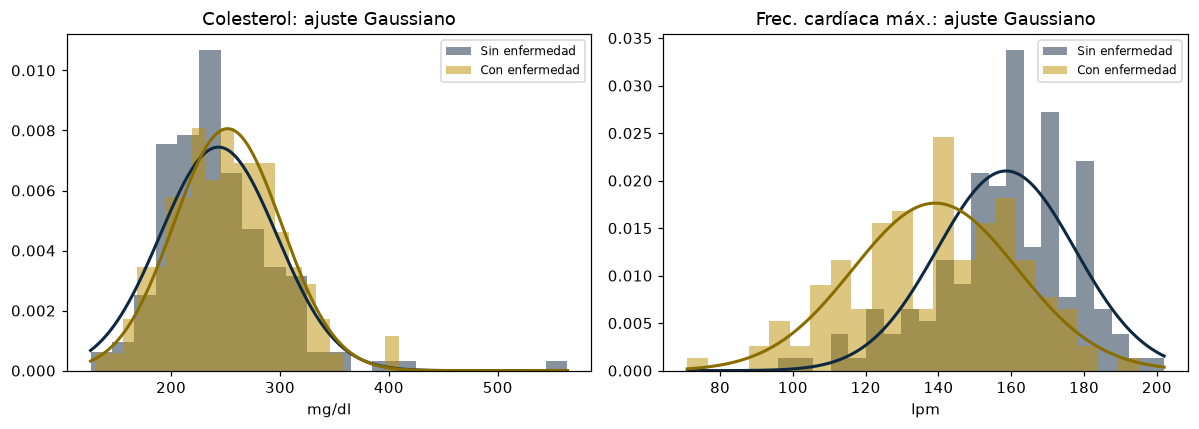

In [10]:
# Histogramas y Gaussianas ajustadas

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

variables = [
    (
        chol_D, chol_noD,
        mu_chol_D, sd_chol_D,
        mu_chol_noD, sd_chol_noD,
        "Colesterol", "mg/dl"
    ),
    (
        thal_D, thal_noD,
        mu_thal_D, sd_thal_D,
        mu_thal_noD, sd_thal_noD,
        "Frec. cardíaca máx.", "lpm"
    )
]

for ax, (a, b, mA, sA, mB, sB, nombre, unidad) in zip(axes, variables):

    ax.hist(
        b, bins=22, density=True,
        alpha=0.5, color=AZUL,
        label="Sin enfermedad"
    )

    ax.hist(
        a, bins=22, density=True,
        alpha=0.5, color=ORO,
        label="Con enfermedad"
    )

    x = np.linspace(
        min(a.min(), b.min()),
        max(a.max(), b.max()),
        250
    )

    ax.plot(x, stats.norm.pdf(x, mB, sB), color=AZUL, lw=2)
    ax.plot(x, stats.norm.pdf(x, mA, sA), color="#8a6d00", lw=2)

    ax.set_title(f"{nombre}: ajuste Gaussiano")
    ax.set_xlabel(unidad)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación clínica:** 
Para el colesterol, las dos Gaussianas quedan bastante parecidas: la media es de **251.9 mg/dl** en pacientes con enfermedad y **243.5 mg/dl** en pacientes sin enfermedad. La diferencia es de **8.4 mg/dl** y el valor de $p = 0.165$, por lo que no hay evidencia suficiente para considerar que los dos grupos sean diferentes en colesterol.
En cambio, para `thalach`, las medias son **139.1 y 158.6 lpm**, y el valor de $p < 0.001$ muestra una diferencia estadísticamente significativa entre los dos grupos. En esta muestra, la **frecuencia cardíaca máxima parece distinguir mejor entre pacientes con y sin enfermedad que el colesterol**.


Comparación de distribuciones: Para comprobar si la distribución Normal era una buena aproximación para el colesterol, la comparamos con una distribución Log-Normal usando la log-verosimilitud y el AIC.
El **AIC más bajo** indica un mejor ajuste teniendo en cuenta también la cantidad de parámetros. En este caso, la Log-Normal obtuvo un AIC menor (**3163.0 frente a 3192.9**), por lo que describe mejor los datos.
Esto tiene sentido porque el colesterol presenta una **cola hacia la derecha**, con algunos valores bastante altos, algo que la distribución Normal no representa tan bien.

## 5. Distribuciones paramétricas

**Pregunta:** ¿qué "molde" probabilístico corresponde a cada variable? Elegir mal el molde invalida
todo lo que se construya encima (verosimilitudes, modelos, reglas de decisión).

In [11]:
# Distribuciones para las variables

print("1) sex -> Bernoulli")
print(f"p(hombre) = {df['sex'].mean():.4f}\n")

print("2) cp -> Categórica")
print(df["cp_label"].value_counts(normalize=True).round(4).to_string(), "\n")

print("3) chol -> Gaussiana aproximada")
print(f"mu = {df['chol'].mean():.2f}   sigma = {df['chol'].std(ddof=0):.2f}")
print(f"Asimetría = {stats.skew(df['chol']):.3f}\n")

print("4) thalach -> Gaussiana")
print(f"mu = {df['thalach'].mean():.2f}   sigma = {df['thalach'].std(ddof=0):.2f}")
print(f"Asimetría = {stats.skew(df['thalach']):.3f}")

# Pruebas de normalidad

print(f"\nShapiro-Wilk chol    : p = {stats.shapiro(df['chol']).pvalue:.2e}")
print(f"Shapiro-Wilk thalach : p = {stats.shapiro(df['thalach']).pvalue:.4f}")

1) sex -> Bernoulli
p(hombre) = 0.6768

2) cp -> Categórica
cp_label
Asintomático      0.4781
No anginoso       0.2795
Angina atípica    0.1650
Angina típica     0.0774 

3) chol -> Gaussiana aproximada
mu = 247.35   sigma = 51.91
Asimetría = 1.112

4) thalach -> Gaussiana
mu = 149.60   sigma = 22.90
Asimetría = -0.534

Shapiro-Wilk chol    : p = 1.02e-08
Shapiro-Wilk thalach : p = 0.0001


**Interpretación:** `sex` y `enfermedad` son variables Bernoulli, mientras que `cp`, `slope` y `thal` son variables categóricas. No tendría sentido tratarlas como variables numéricas ordenadas, porque los valores son códigos de categorías. Por ejemplo, que `cp = 4` no significa que sea el doble de `cp = 2`.
Para las variables continuas, `thalach` es razonablemente cercana a una Gaussiana, con una asimetría de **−0.53**. En cambio, `chol` presenta una asimetría positiva de **1.11** y una cola hacia valores altos, llegando hasta **564 mg/dl**, por lo que la Gaussiana se usa solo como una aproximación.

**Nota sobre la normalidad:** La prueba de Shapiro-Wilk rechaza la normalidad estricta para ambas variables (`p = 1.0e-08` para `chol` y `p = 1.0e-04` para `thalach`). Sin embargo, la decisión sobre la distribución no se basa únicamente en este resultado. También se tiene en cuenta la forma de los datos, la asimetría y, en el caso del colesterol, la comparación mediante AIC.

Por esto, `thalach` se puede modelar razonablemente con una Gaussiana como aproximación, mientras que para `chol` la Log-Normal resulta más adecuada.

## 6. Esperanza y Varianza

**Pregunta clínica:** ¿los pacientes enfermos se diferencian solo en el **nivel promedio** de su
frecuencia cardíaca máxima, o también en su **variabilidad**? La distinción importa: una varianza
mayor significa que el mismo valor de referencia sirve peor para ese grupo.

In [12]:
# Esperanza y varianza por grupo

for nombre, a, b in [
    ("thalach (lpm)", thal_D, thal_noD),
    ("chol (mg/dl)", chol_D, chol_noD)
]:
    print(nombre)
    print(
        f"   E[X | D]  = {a.mean():7.2f}   "
        f"Var(X | D)  = {a.var(ddof=1):8.2f}   "
        f"sd = {a.std(ddof=1):6.2f}"
    )
    print(
        f"   E[X | ¬D] = {b.mean():7.2f}   "
        f"Var(X | ¬D) = {b.var(ddof=1):8.2f}   "
        f"sd = {b.std(ddof=1):6.2f}"
    )

    lev = stats.levene(a, b)
    print(f"   Levene: p = {lev.pvalue:.4f}\n")

# Coeficiente de variación de thalach

print(f"CV thalach | D  = {thal_D.std(ddof=1) / thal_D.mean():.4f}")
print(f"CV thalach | ¬D = {thal_noD.std(ddof=1) / thal_noD.mean():.4f}")

thalach (lpm)
   E[X | D]  =  139.11   Var(X | D)  =   515.77   sd =  22.71
   E[X | ¬D] =  158.58   Var(X | ¬D) =   362.65   sd =  19.04
   Levene: p = 0.0140

chol (mg/dl)
   E[X | D]  =  251.85   Var(X | D)  =  2468.10   sd =  49.68
   E[X | ¬D] =  243.49   Var(X | ¬D) =  2889.87   sd =  53.76
   Levene: p = 0.7210

CV thalach | D  = 0.1633
CV thalach | ¬D = 0.1201


**Interpretación clínica:** 
Se calcula la media y la varianza de `chol` y `thalach` para los pacientes con y sin enfermedad. La media permite comparar el valor central de cada grupo, mientras que la varianza y la desviación estándar muestran qué tan dispersos están los datos.
También se aplica la prueba de **Levene** para comparar las varianzas entre los dos grupos. Un valor de $p$ pequeño indica evidencia de que las varianzas son diferentes. Por último, se calcula el coeficiente de variación de `thalach` para comparar la dispersión relativa entre los dos grupos.

En `thalach`, los pacientes con enfermedad presentan una frecuencia cardíaca máxima promedio **19.5 lpm menor** que los pacientes sin enfermedad (**139.1 vs 158.6 lpm**). Además, tienen una mayor varianza (**515.8 vs 362.7**) y la prueba de Levene da **p = 0.014**, por lo que hay evidencia de que las varianzas son diferentes. Esto indica que la respuesta al esfuerzo es más variable entre los pacientes con enfermedad.

Por esto, un único umbral de frecuencia cardíaca podría no funcionar igual de bien para todos los pacientes, por lo que conviene interpretarlo junto con otras variables.
En cambio, para el colesterol las varianzas no presentan una diferencia estadísticamente significativa (**p = 0.721**). Esto se suma a lo observado anteriormente: en esta muestra, el colesterol no muestra una diferencia clara entre los grupos ni en su valor promedio ni en su dispersión.

## 7. Independencia y Correlación

**Pregunta clínica:** ¿qué variables están realmente asociadas con la enfermedad y cuáles son
independientes de ella? Y entre las numéricas, ¿hay redundancia (multicolinealidad) que haga
inestable un modelo?

Para variables categóricas usamos **chi-cuadrado de independencia** y **V de Cramér** (tamaño del
efecto): la prueba dice *si* hay relación, la V dice *cuánta*.

In [13]:
def chi2_test(var, etiqueta):
    tabla = pd.crosstab(df[var], df["enfermedad"])
    chi2, pval, dof, esperado = stats.chi2_contingency(tabla)

    V = np.sqrt(chi2 / (N * (min(tabla.shape) - 1)))

    print(
        f"{etiqueta:28s} "
        f"chi2 = {chi2:7.2f}   "
        f"gl = {dof}   "
        f"p = {pval:.3g}   "
        f"V de Cramér = {V:.3f}"
    )

    return chi2, pval, V


print("PRUEBAS DE INDEPENDENCIA CONTRA 'enfermedad'\n" + "-" * 78)

chi2_test("sex", "sexo")
chi2_test("cp", "tipo de dolor de pecho")
chi2_test("exang", "angina por ejercicio")
chi2_test("thal", "prueba de talio")
chi2_test("fbs", "glucemia en ayunas > 120")

print("\nTabla de contingencia sexo x enfermedad:")
print(
    pd.crosstab(
        df["sex"],
        df["enfermedad"],
        margins=True
    ).to_string()
)

print(f"\nP(D | hombre) = {df.loc[df.sex == 1, 'enfermedad'].mean():.4f}")
print(f"P(D | mujer)  = {df.loc[df.sex == 0, 'enfermedad'].mean():.4f}")

PRUEBAS DE INDEPENDENCIA CONTRA 'enfermedad'
------------------------------------------------------------------------------
sexo                         chi2 =   21.85   gl = 1   p = 2.95e-06   V de Cramér = 0.271
tipo de dolor de pecho       chi2 =   77.28   gl = 3   p = 1.18e-16   V de Cramér = 0.510
angina por ejercicio         chi2 =   50.94   gl = 1   p = 9.51e-13   V de Cramér = 0.414
prueba de talio              chi2 =   82.46   gl = 2   p = 1.24e-18   V de Cramér = 0.527
glucemia en ayunas > 120     chi2 =    0.00   gl = 1   p = 1   V de Cramér = 0.000

Tabla de contingencia sexo x enfermedad:
enfermedad    0    1  All
sex                      
0            71   25   96
1            89  112  201
All         160  137  297

P(D | hombre) = 0.5572
P(D | mujer)  = 0.2604


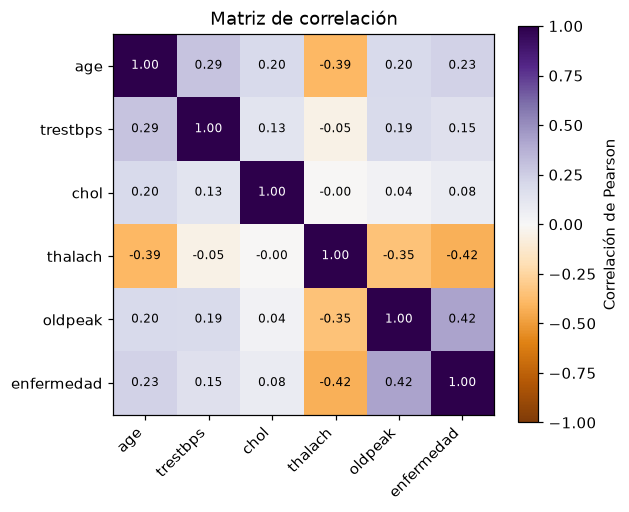

Correlación de cada variable con 'enfermedad':
oldpeak     0.424
thalach    -0.424
age         0.227
trestbps    0.153
chol        0.080

Mayor correlación entre predictoras: age-thalach = -0.395


In [14]:
# Correlación entre variables numéricas

numericas = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "enfermedad"
]

corr = df[numericas].corr()

fig = plt.figure(figsize=(5.8, 4.8))

plt.imshow(corr, cmap="PuOr", vmin=-1, vmax=1)
plt.colorbar(label="Correlación de Pearson")

plt.xticks(
    range(len(numericas)),
    numericas,
    rotation=45,
    ha="right"
)

plt.yticks(range(len(numericas)), numericas)

for i in range(len(numericas)):
    for j in range(len(numericas)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(corr.iloc[i, j]) > 0.55 else "black"
        )

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

print("Correlación de cada variable con 'enfermedad':")
print(
    corr["enfermedad"]
    .drop("enfermedad")
    .sort_values(key=abs, ascending=False)
    .round(3)
    .to_string()
)

print(
    f"\nMayor correlación entre predictoras: "
    f"age-thalach = {corr.loc['age', 'thalach']:.3f}"
)

**Interpretación clínica:** El sexo no es independiente de la enfermedad en esta muestra
($\chi^2 = 21.85$, $p < 0.001$, $V = 0.271$). La enfermedad aparece en el **55.7% de los hombres**
frente al **26.0% de las mujeres**. Aunque existe una asociación, el tamaño del efecto es moderado.
Además, el tipo de dolor de pecho presenta una asociación más fuerte ($V = 0.510$), por lo que el sexo
puede ser una variable útil para segmentar, pero no debería tomarse como el criterio principal.

En cambio, `fbs` (glucemia en ayunas) presenta $\chi^2 \approx 0.00$ y $p = 1.000$, por lo que no
se encuentra evidencia de asociación con la enfermedad en esta población. Esto indica que, al menos
en esta muestra, esta variable no aporta información para distinguir entre pacientes con y sin
enfermedad.

En cuanto a las variables numéricas, `thalach` (**−0.42**) y `oldpeak` (**+0.42**) presentan las
mayores correlaciones con `enfermedad`, mientras que `chol` tiene una correlación de apenas **0.08**.
Además, ninguna pareja de variables predictoras supera $|r| = 0.5$, por lo que no se observa una
correlación alta entre ellas que sugiera un problema importante de multicolinealidad.

## 8. Prior y Posterior (actualización bayesiana secuencial)

**Pregunta clínica:** un paciente entra al consultorio. Antes de cualquier prueba, la mejor
estimación es la tasa base (**prior**). Van llegando tres resultados; ¿cómo evoluciona la sospecha?

Trabajamos en **odds**, donde Bayes se vuelve una multiplicación limpia:
$$\text{odds}_{\text{post}} = \text{odds}_{\text{prior}} \times LR_1 \times LR_2 \times LR_3,
\qquad LR_i = \frac{P(E_i \mid D)}{P(E_i \mid \neg D)}$$

Esto asume **independencia condicional** de las pruebas dado el diagnóstico (supuesto *naive Bayes*),
que discutimos al final de la sección.

In [15]:
# Razón de verosimilitud de cada evidencia

evidencias = {
    "exang = 1 (angina por ejercicio)": df["exang"] == 1,
    "ca > 0 (vasos afectados)": df["ca"] > 0,
    "thal = 7 (defecto reversible)": df["thal"] == 7
}

LR = {}

print("PRUEBA                                P(E|D)    P(E|¬D)     LR+")
print("-" * 68)

for nombre, mask in evidencias.items():
    a = mask[df.enfermedad == 1].mean()
    b = mask[df.enfermedad == 0].mean()

    LR[nombre] = a / b

    print(f"{nombre:36s} {a:.4f}    {b:.4f}    {a / b:.3f}")


# Actualización de la probabilidad usando odds

odds = prior / (1 - prior)

print(f"\nPrior: P(D) = {prior:.4f}   odds = {odds:.4f}")

trayectoria = [prior]

for nombre, lr in LR.items():
    odds *= lr
    p_post = odds / (1 + odds)

    trayectoria.append(p_post)

    print(
        f"+ {nombre:36s} -> "
        f"P(D | evidencia) = {p_post:.4f} ({p_post:.1%})"
    )

PRUEBA                                P(E|D)    P(E|¬D)     LR+
--------------------------------------------------------------------
exang = 1 (angina por ejercicio)     0.5401    0.1437    3.758
ca > 0 (vasos afectados)             0.6715    0.1938    3.466
thal = 7 (defecto reversible)        0.6423    0.1688    3.806

Prior: P(D) = 0.4613   odds = 0.8563
+ exang = 1 (angina por ejercicio)     -> P(D | evidencia) = 0.7629 (76.3%)
+ ca > 0 (vasos afectados)             -> P(D | evidencia) = 0.9177 (91.8%)
+ thal = 7 (defecto reversible)        -> P(D | evidencia) = 0.9770 (97.7%)


In [16]:
# Comparar los diferentes órdenes de las pruebas

print("Probabilidad posterior según el orden de las pruebas:\n")

finales = []

for orden in itertools.permutations(evidencias.keys()):
    o = prior / (1 - prior)
    camino = []

    for k in orden:
        o *= LR[k]
        camino.append(o / (1 + o))

    finales.append(camino[-1])

    etiquetas = " -> ".join(k.split(" ")[0] for k in orden)

    print(
        f"{etiquetas:26s} : "
        + "  ".join(f"{c:.4f}" for c in camino)
    )

print(
    f"\nPosterior final - mínimo: {min(finales):.6f}   "
    f"máximo: {max(finales):.6f}"
)


# Comparar con el resultado observado en los datos

los_tres = (
    (df.exang == 1)
    & (df.ca > 0)
    & (df.thal == 7)
)

posterior_empirico = df.loc[
    los_tres, "enfermedad"
].mean()

print(f"\nPosterior por el modelo = {finales[0]:.4f}")
print(
    f"Posterior por conteo = {posterior_empirico:.4f} "
    f"(n = {los_tres.sum()})"
)

Probabilidad posterior según el orden de las pruebas:

exang -> ca -> thal        : 0.7629  0.9177  0.9770
exang -> thal -> ca        : 0.7629  0.9245  0.9770
ca -> exang -> thal        : 0.7480  0.9177  0.9770
ca -> thal -> exang        : 0.7480  0.9187  0.9770
thal -> exang -> ca        : 0.7652  0.9245  0.9770
thal -> ca -> exang        : 0.7652  0.9187  0.9770

Posterior final - mínimo: 0.976983   máximo: 0.976983

Posterior por el modelo = 0.9770
Posterior por conteo = 0.9429 (n = 35)


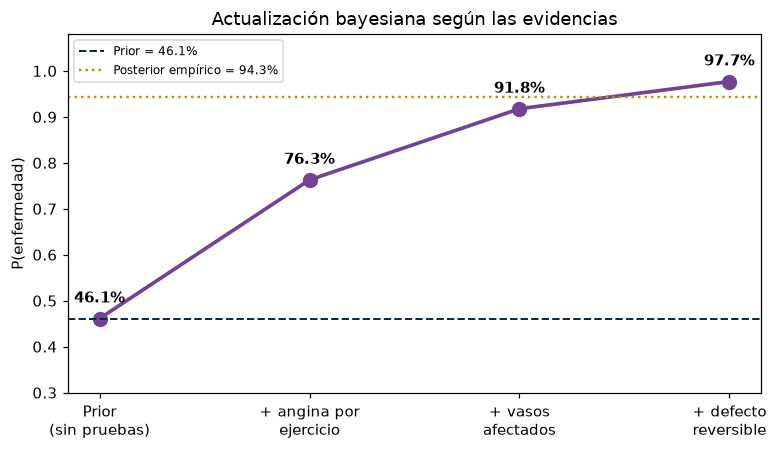

In [17]:
# Gráfico de actualización de la probabilidad

posterior_empirico = df.loc[los_tres, "enfermedad"].mean()

fig = plt.figure(figsize=(7.2, 4.2))

etapas = [
    "Prior\n(sin pruebas)",
    "+ angina por\nejercicio",
    "+ vasos\nafectados",
    "+ defecto\nreversible"
]

plt.plot(
    etapas,
    trayectoria,
    marker="o",
    lw=2.4,
    color=MORADO,
    markersize=9
)

for i, v in enumerate(trayectoria):
    plt.text(
        i,
        v + 0.035,
        f"{v:.1%}",
        ha="center",
        fontweight="bold"
    )

plt.axhline(
    prior,
    color=AZUL,
    ls="--",
    lw=1.3,
    label=f"Prior = {prior:.1%}"
)

plt.axhline(
    posterior_empirico,
    color=ORO,
    ls=":",
    lw=1.6,
    label=f"Posterior empírico = {posterior_empirico:.1%}"
)

plt.ylabel("P(enfermedad)")
plt.ylim(0.3, 1.08)
plt.legend(fontsize=8)
plt.title("Actualización bayesiana según las evidencias")
plt.tight_layout()
plt.show()

**Interpretación clínica:** Las tres evidencias hacen que la probabilidad calculada de enfermedad pase de **46.1% a 97.7%**.
Es un aumento importante de la sospecha, aunque este 97.7% debe interpretarse como el resultado del
modelo bayesiano simplificado y no como una confirmación clínica definitiva.

1. **El orden no cambia el resultado final**, ya que las seis permutaciones terminan en **97.7%**,
   aunque sí cambia el camino que sigue la probabilidad. Como la primera prueba ya aumenta la
   probabilidad hasta aproximadamente 75%, en un escenario donde se asumieran estos mismos costos
   y supuestos podría tener sentido priorizar las pruebas más sencillas y actualizar la decisión
   progresivamente.

2. **El supuesto del modelo tiene una diferencia medible:** el conteo directo de los **35 pacientes**
   que presentan las tres señales da una probabilidad de **94.3%**, frente al **97.7%** obtenido al
   multiplicar los LR+. La diferencia muestra que las evidencias no son completamente independientes
   y que el modelo multiplicativo tiende a sobreestimar un poco la probabilidad final.

Por eso, el **97.7% sirve para ilustrar la actualización bayesiana bajo el supuesto utilizado**, pero
la comparación con el 94.3% observado en los datos es importante para mostrar las limitaciones del
modelo.

## 9. Entropía

**Pregunta clínica:** ¿cuánta incertidumbre diagnóstica hay antes de ver al paciente, y cuánta
elimina cada variable?

$$H(D) = -\sum_i p_i \log_2 p_i, \qquad
H(D \mid X) = \sum_x P(x)\,H(D \mid X = x), \qquad IG = H(D) - H(D\mid X)$$

In [18]:
def entropia_bits(p):
    p = np.array(p, dtype=float)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


# Entropía de la variable objetivo

H_D = entropia_bits([p_D, 1 - p_D])

print(f"H(enfermedad) = {H_D:.4f} bits")
print(f"Máximo para dos clases = 1.0000 bits")
print(f"Proporciones: {p_D:.1%} / {1 - p_D:.1%}\n")


# Entropía condicionada al tipo de dolor de pecho

H_D_cp = 0

print("Entropía por tipo de dolor:")

for etiqueta, g in df.groupby("cp_label"):
    peso = len(g) / N
    h = entropia_bits(
        g["enfermedad"].value_counts(normalize=True).values
    )

    H_D_cp += peso * h

    print(f"{etiqueta:16s} peso = {peso:.3f}   H = {h:.4f} bits")

ganancia = H_D - H_D_cp

print(f"\nH(enfermedad | cp) = {H_D_cp:.4f} bits")
print(f"Ganancia de información = {ganancia:.4f} bits")
print(f"Reducción de incertidumbre = {ganancia / H_D:.1%}")

H(enfermedad) = 0.9957 bits
Máximo para dos clases = 1.0000 bits
Proporciones: 46.1% / 53.9%

Entropía por tipo de dolor:
Angina atípica   peso = 0.165   H = 0.6880 bits
Angina típica    peso = 0.077   H = 0.8865 bits
Asintomático     peso = 0.478   H = 0.8481 bits
No anginoso      peso = 0.279   H = 0.7544 bits

H(enfermedad | cp) = 0.7985 bits
Ganancia de información = 0.1972 bits
Reducción de incertidumbre = 19.8%


variable  H(D|X)  Ganancia
    thal  0.7854    0.2102
      cp  0.7985    0.1972
      ca  0.8110    0.1846
   exang  0.8634    0.1323
   slope  0.8869    0.1088
     sex  0.9378    0.0579
 restecg  0.9722    0.0235
     fbs  0.9957    0.0000


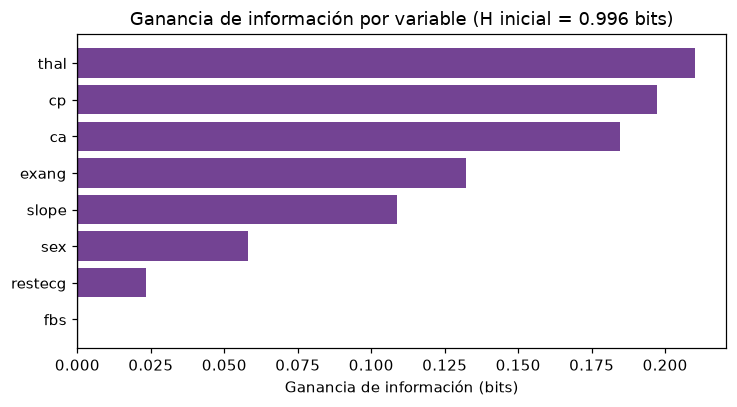

In [19]:
# Ganancia de información de cada variable

variables = ["cp", "thal", "ca", "exang", "slope", "sex", "restecg", "fbs"]

filas = []

for v in variables:
    h_cond = sum(
        len(g) / N *
        entropia_bits(
            g["enfermedad"].value_counts(normalize=True).values
        )
        for _, g in df.groupby(v)
    )

    filas.append({
        "variable": v,
        "H(D|X)": round(h_cond, 4),
        "Ganancia": round(H_D - h_cond, 4)
    })

ranking = (
    pd.DataFrame(filas)
    .sort_values("Ganancia", ascending=False)
    .reset_index(drop=True)
)

print(ranking.to_string(index=False))


# Gráfico

fig = plt.figure(figsize=(6.8, 3.8))

plt.barh(
    ranking["variable"][::-1],
    ranking["Ganancia"][::-1],
    color=MORADO
)

plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Ganancia de información (bits)")
plt.title(f"Ganancia de información por variable (H inicial = {H_D:.3f} bits)")
plt.tight_layout()
plt.show()

**Interpretación clínica:** La entropía inicial es de **0.996 bits**, muy cercana al máximo de 1 bit para una variable con dos
clases. Esto indica que, antes de incorporar información adicional, existe bastante incertidumbre
sobre si un paciente tiene o no la enfermedad. La prevalencia de **46.1%** también muestra que esta
base corresponde a una población que ya llega con cierta sospecha, y no a la población general.

Conocer el tipo de dolor de pecho reduce la entropía a **0.799 bits**, lo que representa una
ganancia de **0.197 bits**, aproximadamente el **20% de la incertidumbre inicial**. Por lo tanto,
el tipo de dolor aporta información y puede orientar el diagnóstico, pero por sí solo deja una parte
importante de la incertidumbre.

Ninguna de las variables analizadas supera los **0.22 bits de ganancia de información**, lo que
indica que ninguna variable individual explica por sí sola una gran parte de la incertidumbre. Esto
refuerza la idea de que es necesario combinar varias señales para obtener una mejor capacidad de
discriminación.

Por otro lado, `fbs` aporta **0.0000 bits** de ganancia de información, lo que coincide con el
resultado obtenido anteriormente en la prueba $\chi^2$, donde prácticamente no se encontró
asociación con la enfermedad.

## 10. Entropía cruzada

**Pregunta clínica:** ¿un modelo que combine todas las variables aporta información real, o solo
reproduce la tasa base?

La entropía cruzada (log-loss) mide cuántos *nats* de sorpresa tiene el modelo frente a la realidad;
castiga fuerte asignar baja probabilidad a la clase correcta:
$$H(p, q) = -\frac{1}{n}\sum_i \big[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \big]$$

In [20]:
# Preparar las variables

X = pd.get_dummies(
    df[
        [
            "age", "sex", "cp", "trestbps", "chol", "thalach",
            "exang", "oldpeak", "slope", "ca", "thal"
        ]
    ],
    columns=["cp", "slope", "thal"],
    drop_first=True
).astype(float)

y = df["enfermedad"].values


# Separar entrenamiento y prueba

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)


# Regresión logística

modelo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

modelo.fit(X_tr, y_tr)

p_tr = modelo.predict_proba(X_tr)[:, 1]
p_te = modelo.predict_proba(X_te)[:, 1]


# Entropía cruzada

ce_train = log_loss(y_tr, p_tr)
ce_test = log_loss(y_te, p_te)


# Modelo base

ce_base = log_loss(
    y_te,
    np.full(len(y_te), y_tr.mean())
)

print(f"Entropía cruzada - entrenamiento : {ce_train:.4f} nats")
print(f"Entropía cruzada - prueba        : {ce_test:.4f} nats")
print(f"Línea base                       : {ce_base:.4f} nats")
print(f"H(enfermedad) en nats            : {H_D * np.log(2):.4f} nats")

print(f"\nReducción frente a la línea base : {(1 - ce_test / ce_base):.1%}")
print(f"Exactitud en prueba              : {accuracy_score(y_te, modelo.predict(X_te)):.4f}")
print(f"AUC-ROC en prueba                : {roc_auc_score(y_te, p_te):.4f}")
print(f"\nBrecha train-test                : {ce_test - ce_train:+.4f} nats")

Entropía cruzada - entrenamiento : 0.3394 nats
Entropía cruzada - prueba        : 0.3241 nats
Línea base                       : 0.6910 nats
H(enfermedad) en nats            : 0.6901 nats

Reducción frente a la línea base : 53.1%
Exactitud en prueba              : 0.8667
AUC-ROC en prueba                : 0.9379

Brecha train-test                : -0.0154 nats


**Interpretación clínica:** El modelo reduce la entropía cruzada de **0.691 nats** en la línea base a **0.324 nats** en el
conjunto de prueba, lo que representa una reducción del **53%**. Además, obtiene un **AUC-ROC de
0.938**, por lo que logra separar bastante bien a los pacientes con y sin enfermedad.

La pérdida en prueba es incluso ligeramente menor que la de entrenamiento (**0.324 vs 0.339 nats**).
No se observa una brecha que sugiera un problema evidente de sobreajuste y, en esta partición, el
modelo mantiene un buen desempeño sobre datos que no utilizó para entrenarse.

En términos prácticos, combinar las variables disponibles en la historia clínica aporta información
útil para distinguir entre pacientes con y sin enfermedad. Por esto, el modelo podría utilizarse como
apoyo para la **priorización de pacientes**, pero no como sustituto del criterio médico.

## 11. Divergencia KL

**Pregunta clínica:** ¿qué tan distinguibles son enfermos y sanos mirando **una sola variable**?
La divergencia KL mide el "impuesto en bits" que se paga por usar la distribución equivocada:

$$D_{KL}(P \parallel Q) = \sum_i P(i) \log_2 \frac{P(i)}{Q(i)}$$

Cuanto mayor sea, más separadas están las poblaciones y más útil es esa variable por sí sola.

In [21]:
def kl_bits(a, b, n_bins=10):
    bordes = np.linspace(
        min(a.min(), b.min()),
        max(a.max(), b.max()),
        n_bins + 1
    )

    hp, _ = np.histogram(a, bins=bordes)
    hq, _ = np.histogram(b, bins=bordes)

    eps = 1e-9

    P = (hp + eps) / (hp.sum() + eps * n_bins)
    Q = (hq + eps) / (hq.sum() + eps * n_bins)

    return np.sum(P * np.log2(P / Q))


variables = ["chol", "trestbps", "age", "thalach", "oldpeak"]

print("Divergencia KL entre pacientes con y sin enfermedad\n")
print(f"{'variable':12s} {'KL(D||¬D)':>11s} {'KL(¬D||D)':>11s}")
print("-" * 40)

resultados = {}

for v in variables:
    a = df.loc[df.enfermedad == 1, v].values
    b = df.loc[df.enfermedad == 0, v].values

    kl_ab = kl_bits(a, b)
    kl_ba = kl_bits(b, a)

    resultados[v] = kl_ab

    print(f"{v:12s} {kl_ab:11.4f} {kl_ba:11.4f}")


print("\nComparación usando el colesterol como referencia:")

for v, k in sorted(resultados.items(), key=lambda x: -x[1]):
    print(
        f"{v:10s} {k:.4f} bits   "
        f"= {k / resultados['chol']:.1f}x el colesterol"
    )

Divergencia KL entre pacientes con y sin enfermedad

variable       KL(D||¬D)   KL(¬D||D)
----------------------------------------
chol              0.0800      0.2446
trestbps          0.5017      0.0945
age               0.3154      0.4770
thalach           0.8932      0.6435
oldpeak           1.4234      0.6040

Comparación usando el colesterol como referencia:
oldpeak    1.4234 bits   = 17.8x el colesterol
thalach    0.8932 bits   = 11.2x el colesterol
trestbps   0.5017 bits   = 6.3x el colesterol
age        0.3154 bits   = 3.9x el colesterol
chol       0.0800 bits   = 1.0x el colesterol


In [22]:
# ¿Cambia el ranking si cambio el número de intervalos?
rejilla_bins = [5, 8, 10, 12, 15, 20, 25]

tabla_sens = {}
for nb_ in rejilla_bins:
    tabla_sens[nb_] = {
        v: kl_bits(df.loc[df.enfermedad == 1, v].values,
                   df.loc[df.enfermedad == 0, v].values, nb_)
        for v in variables
    }

sens = pd.DataFrame(tabla_sens).T
sens.index.name = "n_bins"
print("Divergencia KL (bits) según el número de intervalos:")
print(sens.round(4).to_string())

print("\nPosición del colesterol en el ranking:")
for nb_ in rejilla_bins:
    orden = sorted(variables, key=lambda v: -tabla_sens[nb_][v])
    print(f"   {nb_:2d} intervalos -> colesterol es el #{orden.index('chol') + 1} de 5"
          f"   |  oldpeak/chol = {tabla_sens[nb_]['oldpeak'] / tabla_sens[nb_]['chol']:.1f}x")

Divergencia KL (bits) según el número de intervalos:
          chol  trestbps     age  thalach  oldpeak
n_bins                                            
5       0.0322    0.0778  0.2332   0.5475   1.0782
8       0.0672    0.5294  0.3049   0.8427   1.1887
10      0.0800    0.5017  0.3154   0.8932   1.4234
12      0.1126    0.5383  0.3088   1.3269   1.9797
15      0.1722    0.5977  0.3551   1.0786   2.0992
20      0.2469    1.0042  0.3708   1.9155   3.5149
25      0.2567    1.0501  0.4337   1.5073   3.7752

Posición del colesterol en el ranking:
    5 intervalos -> colesterol es el #5 de 5   |  oldpeak/chol = 33.5x
    8 intervalos -> colesterol es el #5 de 5   |  oldpeak/chol = 17.7x
   10 intervalos -> colesterol es el #5 de 5   |  oldpeak/chol = 17.8x
   12 intervalos -> colesterol es el #5 de 5   |  oldpeak/chol = 17.6x
   15 intervalos -> colesterol es el #5 de 5   |  oldpeak/chol = 12.2x
   20 intervalos -> colesterol es el #5 de 5   |  oldpeak/chol = 14.2x
   25 intervalos -> co

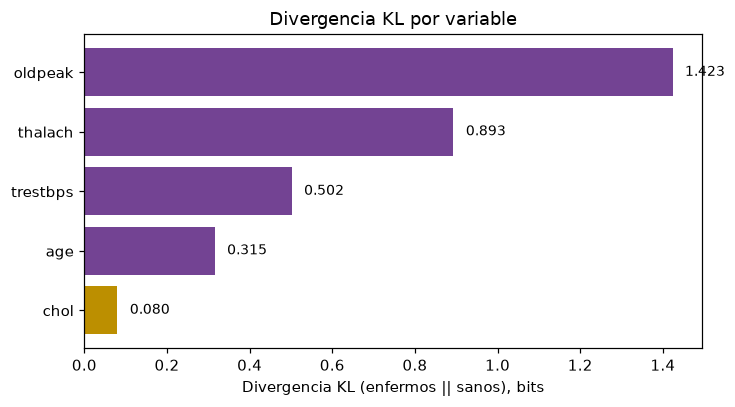

In [23]:
# Gráfico de divergencia KL

fig = plt.figure(figsize=(6.8, 3.8))

vs = sorted(resultados, key=resultados.get)
colores = [ORO if v == "chol" else MORADO for v in vs]

plt.barh(
    vs,
    [resultados[v] for v in vs],
    color=colores
)

for i, v in enumerate(vs):
    plt.text(
        resultados[v] + 0.03,
        i,
        f"{resultados[v]:.3f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Divergencia KL (enfermos || sanos), bits")
plt.title("Divergencia KL por variable")
plt.tight_layout()
plt.show()

**Interpretación clínica — hallazgo central del proyecto:** El colesterol presenta una divergencia de **0.080 bits**, la más baja entre las variables continuas analizadas. En comparación, `oldpeak` alcanza **1.423 bits** y `thalach` **0.893 bits**, lo que
muestra una diferencia mucho mayor entre las distribuciones de pacientes con y sin enfermedad.

Con esta discretización, los valores de colesterol presentan distribuciones bastante similares entre
ambos grupos, por lo que esta variable aporta poca capacidad de diferenciación por sí sola. Esto
coincide con los resultados obtenidos anteriormente: la diferencia de medias no fue
estadísticamente significativa (**p = 0.165**), las varianzas tampoco mostraron diferencias
significativas (**p = 0.721**) y la correlación con `enfermedad` fue muy baja (**r = 0.08**).

En cambio, variables como `oldpeak` y `thalach` muestran una mayor diferencia entre las
distribuciones de ambos grupos. Esto refuerza lo observado en las secciones anteriores, donde
también mostraron una mayor capacidad para diferenciar a los pacientes.

> **Nota:** los valores de KL dependen de la discretización utilizada (en este caso, 10 intervalos),
> por lo que las comparaciones deben interpretarse bajo esta misma configuración.

## Resumen ejecutivo

| # | Concepto | Resultado principal | Interpretación |
|---|---|---|---|
| 1 | Probabilidad condicional | P(D) = 46.1%; P(D\|asintomático) = 72.5% | El tipo de dolor orienta, pero la ausencia de dolor típico no permite descartar enfermedad. |
| 2 | Teorema de Bayes | P(D\|angina por ejercicio) = 76.3%; LR+ = 3.76 | La angina inducida por ejercicio aumenta de forma importante la probabilidad de enfermedad. |
| 3–4 | Verosimilitud / MLE | `chol`: 251.9 vs 243.5 mg/dl (p = 0.165); `thalach`: 139.1 vs 158.6 lpm (p < 0.001) | El colesterol presenta poca diferencia entre grupos, mientras que `thalach` muestra una separación más clara. |
| 5 | Distribuciones paramétricas | `sex` ~ Bernoulli; `cp` ~ Categórica; `thalach` ~ Gaussiana aprox.; `chol` mejor ajustado por Log-Normal | La elección de la distribución debe tener en cuenta las características de cada variable. |
| 6 | Esperanza y varianza | Var(`thalach`\|D) = 515.8 vs 362.7 (Levene p = 0.014) | La frecuencia cardíaca máxima presenta mayor dispersión en el grupo con enfermedad. |
| 7 | Independencia y correlación | Sexo: χ² = 21.85, p < 0.001; `fbs`: χ² ≈ 0, p = 1.000 | `fbs` no muestra asociación con la enfermedad en esta muestra. |
| 8 | Prior y posterior | 46.1% → 97.7% usando las tres evidencias | Combinar varias evidencias aumenta mucho la probabilidad posterior, aunque el supuesto de independencia introduce cierta sobreestimación. |
| 9 | Entropía | H(D) = 0.996 bits; H(D\|cp) = 0.799; IG = 0.197 | El tipo de dolor reduce parte de la incertidumbre, pero no es suficiente por sí solo. |
| 10 | Entropía cruzada | 0.324 nats en prueba vs 0.691 de línea base; AUC = 0.938 | El modelo multivariable mejora claramente respecto a la línea base en esta partición. |
| 11 | Divergencia KL | `chol` = 0.080 bits; `oldpeak` = 1.423 bits | Las distribuciones de colesterol son más parecidas entre grupos que las de otras variables analizadas. |

## Recomendaciones

1. **No utilizar el colesterol como único criterio de discriminación.** En esta muestra presenta una
   diferencia de medias no significativa, una correlación muy baja con la enfermedad y una de las
   menores divergencias KL. Esto no significa que el colesterol no tenga importancia clínica, sino que
   su valor por sí solo discrimina poco entre los dos grupos analizados.

2. **No utilizar la ausencia de angina típica como criterio para descartar enfermedad.** El grupo
   asintomático presentó una probabilidad de enfermedad de **72.5%**, superior a la tasa general de
   46.1%. El tipo de dolor puede aportar información, pero no debería utilizarse de manera aislada.

3. **Combinar diferentes señales en lugar de depender de una sola variable.** Las diferentes
   secciones muestran que `thalach`, `oldpeak`, `cp`, `exang` y otras variables aportan información
   desde perspectivas distintas. La regresión logística obtiene un AUC de **0.938** en el conjunto
   de prueba, lo que respalda el uso de un enfoque multivariable como apoyo.

4. **Usar el modelo como apoyo a la priorización y no como sustituto del criterio médico.** El
   desempeño observado es prometedor, pero debe comprobarse con datos externos antes de utilizarlo
   en una población clínica real.

## Limitaciones

- El análisis utiliza **n = 297** pacientes después de eliminar 6 registros con valores faltantes.
- La base corresponde a pacientes de **Cleveland** y proviene de un contexto clínico de décadas
  atrás, por lo que los resultados pueden no representar a pacientes actuales.
- La prevalencia de **46.1%** corresponde a esta muestra y no a la población general. Por lo tanto,
  el prior debe recalibrarse si el modelo se aplica a una población con una prevalencia diferente.
- Los datos son observacionales, por lo que las asociaciones encontradas **no implican causalidad**.
- El posterior de **97.7%** obtenido al combinar las tres evidencias depende del supuesto de
  independencia. El conteo directo en los pacientes que presentan las tres señales da **94.3%**,
  lo que muestra que el supuesto naive produce cierta sobreestimación.
- La divergencia KL se calculó después de discretizar las variables continuas en **10 intervalos**,
  por lo que sus valores dependen de esta elección.
- El AUC y el log-loss de la regresión logística corresponden a una sola partición entrenamiento/
  prueba. Sería necesario realizar validación externa o, al menos, validación cruzada antes de
  sacar conclusiones sobre su desempeño fuera de esta muestra.